#### 붓꽃 데이터로 PCA 변환을 위한 데이터 로딩 및 시각화

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


0 o
1 s
2 ^


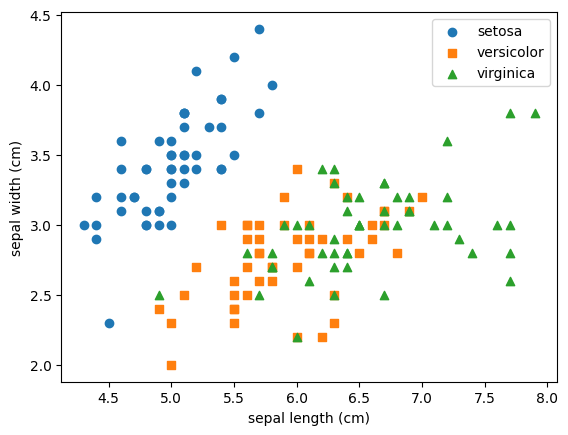

In [ ]:
markers = ['o', 's', '^']

# setosa 의 target 는 0, versicolor 는 1, virginica 는 2
for i, marker in enumerate(markers):
    print(i, marker)
    x_axis_data = df[df['target'] == i]['sepal length (cm)']
    y_axis_data = df[df['target'] == i]['sepal width (cm)']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
    
plt.legend()
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.show()

**평균이 0 분산이 1인 정규 분포로 원본 데이터를 변환**

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

iris_scaled = scaler.fit_transform(df.iloc[:, :-1])

In [7]:
df.shape

(150, 5)

In [ ]:
iris_scaled.shape # target 제외 4개의 feature

(150, 4)

In [9]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # 2차원으로 축소
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)
print(iris_pca.shape) # 150개의 샘플이 2개의 feature로 변환됨

(150, 2)


In [10]:
iris_pca = pca.fit_transform(iris_scaled)
print(iris_pca.shape)

(150, 2)


In [11]:
# PCA 변환된 데이터의 컬럼명을 각각 지정
pca_columns = ['pca_component_1', 'pca_component_2']
irisDF_pca = pd.DataFrame(data=iris_pca, columns=pca_columns)
irisDF_pca['target'] = iris.target
irisDF_pca.head()

,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


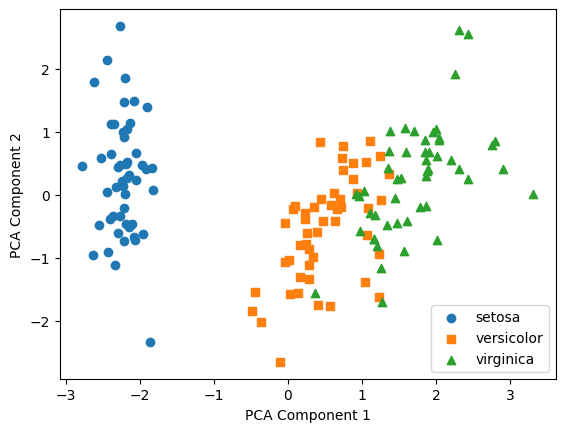

In [12]:
markers = ['o', 's', '^']
for i, marker in enumerate(markers):
    x_axis_data = irisDF_pca[irisDF_pca['target'] == i]['pca_component_1']
    y_axis_data = irisDF_pca[irisDF_pca['target'] == i]['pca_component_2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

**각 PCA Component별 변동성 비율**

In [13]:
print(pca.explained_variance_ratio_) # 각 PCA Component별 변동성 비율

[0.72962445 0.22850762]


**원본 데이터와 PCA 변환된 데이터 기반에서 예측 성능 비교**

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rcf = RandomForestClassifier(random_state=156)
scores = cross_val_score(rcf, iris.data, iris.target, scoring='accuracy', cv=3)
print('원본 데이터 세트 교차 검증 개별 정확도 : ', scores)
print('원본 데이터 세트 교차 검증 평균 정확도 : {0:.3f}'.format(np.mean(scores)))

원본 데이터 세트 교차 검증 개별 정확도 :  [0.98 0.94 0.96]
원본 데이터 세트 교차 검증 평균 정확도 : 0.960


In [16]:
pca_X = irisDF_pca[['pca_component_1', 'pca_component_2']]
scores = cross_val_score(rcf, pca_X, iris.target, scoring='accuracy', cv=3)
print('PCA 변환 데이터 세트 교차 검증 개별 정확도 : ', scores)
print('PCA 변환 데이터 세트 교차 검증 평균 정확도 : {0:.3f}'.format(np.mean(scores)))

PCA 변환 데이터 세트 교차 검증 개별 정확도 :  [0.88 0.88 0.88]
PCA 변환 데이터 세트 교차 검증 평균 정확도 : 0.880
